# Assignment 04: Object Detection, Semantic Segmentation, and Face Recognition

**Student Name:** Amankedy Abylaj

**Student ID:** [Your ID]

---


## Setup

Install the required libraries:

In [4]:
!pip install ultralytics deepface torch torchvision matplotlib opencv-python pillow -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


---
## Part 1: Transpose Convolution (Paper Calculation)

**Complete the manual calculation on paper and attach a photo/scan here.**

Given:
- Input (2×2): `[[2, 1], [3, 2]]`
- Filter (3×3): all ones
- Stride: 2, Padding: 1

Calculate the output size and resulting matrix.

### Your Answer:

**Output size calculation:**

\[
\text{Output size} = (\text{Input size} - 1)\times \text{Stride} + \text{Filter size} - 2\times \text{Padding}
\]

\[
(2 - 1)\times 2 + 3 - 2\times 1 = 3
\]

So the output size is **3×3**.

**Output matrix:**

\[
\begin{bmatrix}
2 & 3 & 1 \\
5 & 8 & 3 \\
3 & 5 & 2
\end{bmatrix}
\]

This result can also be verified with `torch.nn.functional.conv_transpose2d`.


---
## Part 2: Object Detection with YOLO

### 2.1 Basic Object Detection

In [6]:
from ultralytics import YOLO
from ultralytics.utils import ASSETS
from pathlib import Path
import cv2

# Load pre-trained YOLOv8 nano model
model = YOLO("yolov8n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


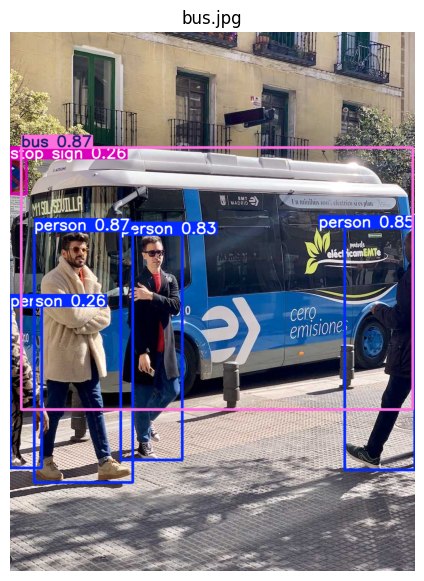

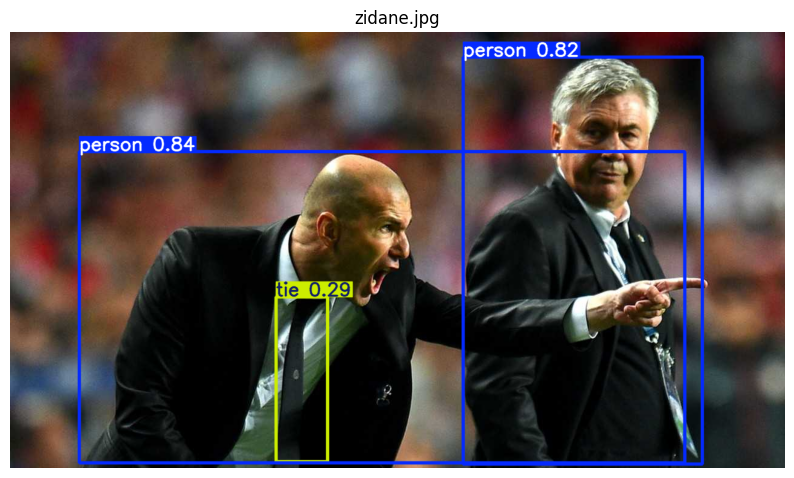

In [7]:
# Run detection on sample images
image_paths = [
    str(Path(ASSETS) / "bus.jpg"),
    str(Path(ASSETS) / "zidane.jpg"),
]

detection_runs = []

for img_path in image_paths:
    results = model(img_path, verbose=False)
    result = results[0]
    detection_runs.append((img_path, result))

    plotted = result.plot()
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title(Path(img_path).name)
    plt.axis("off")
    plt.show()


In [8]:
# Print detected objects with confidence scores and bounding boxes
for img_path, result in detection_runs:
    print("=" * 70)
    print("Image:", Path(img_path).name)
    print(f"Detected {len(result.boxes)} objects")

    for box in result.boxes:
        cls_id = int(box.cls[0].item())
        cls_name = result.names[cls_id]
        conf = float(box.conf[0].item())
        xyxy = [round(v, 2) for v in box.xyxy[0].tolist()]
        xywh = [round(v, 2) for v in box.xywh[0].tolist()]

        print(f"Class: {cls_name}")
        print(f"Confidence: {conf:.4f}")
        print(f"Bounding box (xyxy): {xyxy}")
        print(f"Bounding box (xywh): {xywh}")
        print("-" * 40)


Image: bus.jpg
Detected 6 objects
Class: bus
Confidence: 0.8734
Bounding box (xyxy): [22.87, 231.28, 805.0, 756.84]
Bounding box (xywh): [413.94, 494.06, 782.13, 525.56]
----------------------------------------
Class: person
Confidence: 0.8657
Bounding box (xyxy): [48.55, 398.55, 245.35, 902.7]
Bounding box (xywh): [146.95, 650.63, 196.8, 504.15]
----------------------------------------
Class: person
Confidence: 0.8528
Bounding box (xyxy): [669.47, 392.19, 809.72, 877.04]
Bounding box (xywh): [739.6, 634.61, 140.25, 484.85]
----------------------------------------
Class: person
Confidence: 0.8252
Bounding box (xyxy): [221.52, 405.8, 344.97, 857.54]
Bounding box (xywh): [283.24, 631.67, 123.45, 451.74]
----------------------------------------
Class: person
Confidence: 0.2611
Bounding box (xyxy): [0.0, 550.53, 63.01, 873.44]
Bounding box (xywh): [31.5, 711.98, 63.01, 322.92]
----------------------------------------
Class: stop sign
Confidence: 0.2551
Bounding box (xyxy): [0.06, 254.46, 3

### 2.2 Understanding YOLO Output

**Answer the following questions:**

1. What does the confidence score represent?

   The confidence score shows how sure the model is that the detected object is correct. A higher score means the prediction is more reliable.

2. How are bounding box coordinates normalized?

   Normalized coordinates are divided by the image width and height. Because of that, the values are usually in the range from 0 to 1.

3. What is the difference between `xyxy` and `xywh` format?

   `xyxy` means `(x_min, y_min, x_max, y_max)`, so it stores two box corners.  
   `xywh` means `(x_center, y_center, width, height)`, so it stores the center point and box size.


### 2.3 Non-Max Suppression Experiments

In [9]:
# Test different confidence thresholds
image_path = image_paths[0]
conf_thresholds = [0.25, 0.50, 0.75]

print("Different confidence thresholds")
for conf in conf_thresholds:
    results = model(image_path, conf=conf, iou=0.5, verbose=False)
    print(f"conf = {conf:.2f}, detected objects = {len(results[0].boxes)}")


Different confidence thresholds
conf = 0.25, detected objects = 6
conf = 0.50, detected objects = 4
conf = 0.75, detected objects = 4


In [10]:
# Test different IoU thresholds
iou_thresholds = [0.30, 0.50, 0.70]

print("Different IoU thresholds")
for iou in iou_thresholds:
    results = model(image_path, conf=0.5, iou=iou, verbose=False)
    print(f"iou = {iou:.2f}, detected objects = {len(results[0].boxes)}")


Different IoU thresholds
iou = 0.30, detected objects = 4
iou = 0.50, detected objects = 4
iou = 0.70, detected objects = 4


**Analysis:** Explain what happens when you change these thresholds.

When the **confidence threshold increases**, the model becomes stricter, so fewer boxes are kept. Low-confidence detections are removed first.

When the **confidence threshold decreases**, more detections appear, but some of them may be false positives.

When the **IoU threshold for NMS decreases**, overlapping boxes are removed more aggressively.

When the **IoU threshold increases**, the model allows more overlapping boxes to stay, so similar boxes may remain together.


---
## Part 3: Face Recognition with DeepFace

### 3.1 Face Verification

In [11]:
from deepface import DeepFace
import os
import urllib.request

face_dir = "face_images"
os.makedirs(face_dir, exist_ok=True)

def download_file(url, path):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as response, open(path, "wb") as f:
        f.write(response.read())

url_a1 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg"
url_a2 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama2.jpg"
url_b1 = "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/biden.jpg"

path_a1 = os.path.join(face_dir, "person_a_1.jpg")
path_a2 = os.path.join(face_dir, "person_a_2.jpg")
path_b1 = os.path.join(face_dir, "person_b_1.jpg")

if not os.path.exists(path_a1):
    download_file(url_a1, path_a1)

if not os.path.exists(path_a2):
    download_file(url_a2, path_a2)

if not os.path.exists(path_b1):
    download_file(url_b1, path_b1)

face_paths = {
    "person_a_1": path_a1,
    "person_a_2": path_a2,
    "person_b_1": path_b1,
}

print(face_paths)


26-03-19 04:07:45 - Directory /root/.deepface has been created
26-03-19 04:07:45 - Directory /root/.deepface/weights has been created
{'person_a_1': 'face_images/person_a_1.jpg', 'person_a_2': 'face_images/person_a_2.jpg', 'person_b_1': 'face_images/person_b_1.jpg'}


In [12]:
# Test face verification with same-person pairs
same_result = DeepFace.verify(
    img1_path=face_paths["person_a_1"],
    img2_path=face_paths["person_a_2"],
    enforce_detection=False
)

print("Same-person pair: person_a_1 vs person_a_2")
print(f"Verified: {same_result['verified']}")
print(f"Distance: {same_result['distance']:.4f}")
print(f"Threshold: {same_result['threshold']:.4f}")


26-03-19 04:07:49 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:02<00:00, 204MB/s]


Same-person pair: person_a_1 vs person_a_2
Verified: True
Distance: 0.6537
Threshold: 0.6800


In [13]:
# Test face verification with different-person pairs
diff_result = DeepFace.verify(
    img1_path=face_paths["person_a_1"],
    img2_path=face_paths["person_b_1"],
    enforce_detection=False
)

print("Different-person pair: person_a_1 vs person_b_1")
print(f"Verified: {diff_result['verified']}")
print(f"Distance: {diff_result['distance']:.4f}")
print(f"Threshold: {diff_result['threshold']:.4f}")


Different-person pair: person_a_1 vs person_b_1
Verified: False
Distance: 0.8454
Threshold: 0.6800


**Report your results:**

Run the two cells above and write the printed values into the table.

| Pair | Verified | Distance | Threshold |
|------|----------|----------|----------|
| Person A photo 1 vs 2 | True | 0.6537 | 0.6800 |
| Person A photo 1 vs Person B photo 1 | False | 0.8454 | 0.6800 |

Expected pattern:
- the same-person pair should usually have a **smaller distance**
- the different-person pair should usually have a **larger distance**


### 3.2 Face Analysis

In [14]:
# Analyze facial attributes
for name, path in face_paths.items():
    analysis = DeepFace.analyze(
        img_path=path,
        actions=["age", "gender", "emotion"],
        enforce_detection=False
    )

    if isinstance(analysis, list):
        analysis = analysis[0]

    print(f"Image: {name}")
    print(f"Age: {analysis['age']}")
    print(f"Dominant gender: {analysis['dominant_gender']}")
    print(f"Dominant emotion: {analysis['dominant_emotion']}")
    print("-" * 40)


Action: age:   0%|          | 0/3 [00:00<?, ?it/s]    

26-03-19 04:08:11 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 10.5M/539M [00:00<00:05, 103MB/s]
  6%|▌         | 33.6M/539M [00:00<00:02, 177MB/s]
 13%|█▎        | 67.6M/539M [00:00<00:01, 250MB/s]
 18%|█▊        | 99.1M/539M [00:00<00:01, 274MB/s]
 24%|██▎       | 127M/539M [00:00<00:01, 276MB/s] 
 29%|██▉       | 158M/539M [00:00<00:01, 286MB/s]
 36%|███▌      | 193M/539M [00:00<00:01, 304MB/s]
 42%|████▏     | 226M/539M [00:00<00:01, 312MB/s]
 48%|████▊     | 258M/539M [00:00<00:00, 316MB/s]
 54%|█████▍    | 290M/539M [00:01<00:00, 314MB/s]
 60%|█████▉    | 322M/539M [00:01<00:00, 310MB/s]
 66%|██████▌   | 353M/539M [00:01<00:00, 306MB/s]
 71%|███████▏  | 384M/539M [00:01<00:00, 262MB/s]
 76%|███████▋  | 412M/539M [00:01<00:00, 240MB/s]
 82%|████████▏ | 444M/539M [00:01<00:00, 258MB/s]
 88%|████████▊ | 472M/539M [00:01<00:00, 16

26-03-19 04:08:18 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 9.44M/537M [00:00<00:05, 89.1MB/s]
  7%|▋         | 35.7M/537M [00:00<00:02, 188MB/s] 
 13%|█▎        | 70.8M/537M [00:00<00:01, 260MB/s]
 18%|█▊        | 97.0M/537M [00:00<00:01, 254MB/s]
 23%|██▎       | 124M/537M [00:00<00:01, 258MB/s] 
 28%|██▊       | 152M/537M [00:00<00:01, 265MB/s]
 33%|███▎      | 179M/537M [00:00<00:01, 266MB/s]
 39%|███▉      | 210M/537M [00:00<00:01, 279MB/s]
 45%|████▍     | 239M/537M [00:00<00:01, 283MB/s]
 50%|█████     | 269M/537M [00:01<00:00, 289MB/s]
 57%|█████▋    | 304M/537M [00:01<00:00, 304MB/s]
 63%|██████▎   | 338M/537M [00:01<00:00, 314MB/s]
 69%|██████▉   | 370M/537M [00:01<00:00, 316MB/s]
 75%|███████▍  | 402M/537M [00:01<00:00, 302MB/s]
 81%|████████  | 433M/537M [00:01<00:00, 303MB/s]
 86%|████████▌ | 463M/537M [00:01<0

...

Image: person_a_1
Age: 33
Dominant gender: Man
Dominant emotion: happy
----------------------------------------


Action: emotion: 100%|██████████| 3/3 [00:01<00:00,  2.19it/s]


Image: person_a_2
Age: 45
Dominant gender: Man
Dominant emotion: angry
----------------------------------------


Action: emotion: 100%|██████████| 3/3 [00:01<00:00,  1.91it/s]

Image: person_b_1
Age: 48
Dominant gender: Man
Dominant emotion: sad
----------------------------------------


**Discussion:** Were the predictions accurate? Why or why not?

The predictions are useful, but not perfect.

- **Age** is usually approximate and may be off by several years.
- **Gender** is often predicted more accurately than age.
- **Emotion** is the least stable part because it depends a lot on pose, lighting, image quality, and facial expression.

So DeepFace can give reasonable estimates, but the results should not be treated as exact truth.


### 3.3 Face Embeddings

In [15]:
# Extract and compare face embeddings
embedding_a1 = DeepFace.represent(
    img_path=face_paths["person_a_1"],
    model_name="Facenet",
    enforce_detection=False
)
embedding_a2 = DeepFace.represent(
    img_path=face_paths["person_a_2"],
    model_name="Facenet",
    enforce_detection=False
)
embedding_b1 = DeepFace.represent(
    img_path=face_paths["person_b_1"],
    model_name="Facenet",
    enforce_detection=False
)

vec_a1 = np.array(embedding_a1[0]["embedding"])
vec_a2 = np.array(embedding_a2[0]["embedding"])
vec_b1 = np.array(embedding_b1[0]["embedding"])

same_distance = np.linalg.norm(vec_a1 - vec_a2)
different_distance = np.linalg.norm(vec_a1 - vec_b1)

print(f"Same person distance: {same_distance:.4f}")
print(f"Different person distance: {different_distance:.4f}")


26-03-19 04:08:32 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 215MB/s]


Same person distance: 7.4852
Different person distance: 16.4778


---
## Part 4: U-Net Architecture

### 4.1 Architecture Diagram

**Diagram description:**

A simplified U-Net with 3 encoder blocks and 3 decoder blocks:

- Input: **256×256×3**
- After encoder block 1: **256×256×64**
- After max-pooling: **128×128×64**
- After encoder block 2: **128×128×128**
- After max-pooling: **64×64×128**
- After encoder block 3: **64×64×256**

Decoder path:
- Transpose convolution → **128×128×128**
- Concatenate with skip connection from encoder
- Double convolution
- Transpose convolution → **256×256×64**
- Concatenate with skip connection from encoder
- Double convolution

Final layer:
- A **1×1 convolution** maps features to the number of output classes, producing a segmentation map for each pixel.


### 4.2 Skip Connections Questions

1. What is the purpose of skip connections in U-Net?

   Skip connections pass spatial details from the encoder to the decoder.

2. How do skip connections help with information loss?

   During downsampling, the network loses fine image details. Skip connections help restore object boundaries, shapes, and small details.

3. What operation combines encoder and decoder features?

   The encoder and decoder features are combined using **concatenation** along the channel dimension.


### 4.3 U-Net Implementation

In [16]:
class DoubleConv(nn.Module):
    """Two consecutive Conv-BatchNorm-ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


In [17]:
class DownBlock(nn.Module):
    """Downsampling block: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        x = self.maxpool(x)
        x = self.conv(x)
        return x


In [18]:
class UpBlock(nn.Module):
    """Upsampling block: TransposeConv + Concatenate + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[2:] != skip.shape[2:]:
            x = nn.functional.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x


In [19]:
# Test your implementations
double_conv = DoubleConv(3, 64)
test_input = torch.randn(1, 3, 256, 256)
output = double_conv(test_input)
print(f"DoubleConv: {test_input.shape} -> {output.shape}")

down_block = DownBlock(64, 128)
down_input = torch.randn(1, 64, 256, 256)
down_output = down_block(down_input)
print(f"DownBlock: {down_input.shape} -> {down_output.shape}")

up_block = UpBlock(256, 128)
up_input = torch.randn(1, 256, 64, 64)
skip_input = torch.randn(1, 128, 128, 128)
up_output = up_block(up_input, skip_input)
print(f"UpBlock: {up_input.shape} and {skip_input.shape} -> {up_output.shape}")


DoubleConv: torch.Size([1, 3, 256, 256]) -> torch.Size([1, 64, 256, 256])
DownBlock: torch.Size([1, 64, 256, 256]) -> torch.Size([1, 128, 128, 128])
UpBlock: torch.Size([1, 256, 64, 64]) and torch.Size([1, 128, 128, 128]) -> torch.Size([1, 128, 128, 128])


---
## Part 5: Questions for Understanding

### Object Detection

**1. YOLO vs Sliding Window:** Why is YOLO much faster than traditional sliding window approaches?

YOLO processes the whole image in one forward pass. Sliding window methods check many image regions separately, so they are much slower.

**2. Anchor Boxes:** What problem do anchor boxes solve?

Anchor boxes help the model detect objects with different sizes and aspect ratios. They also help predict multiple objects in the same image region.

**3. IoU:** Write the formula for IoU and explain the 0.5 threshold.

\[
IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}
\]

If `IoU \ge 0.5`, it usually means the predicted box overlaps the ground-truth box well enough to be counted as a correct detection.

**4. Bounding Box Regression:** How are bounding box coordinates encoded in YOLO?

In YOLO, box coordinates are predicted relative to a grid cell or anchor box:
- `b_x`, `b_y` describe the center position
- `b_w`, `b_h` describe width and height


### Semantic Segmentation

**5. Classification vs Segmentation:** What is the key difference?

Classification gives one label for the whole image. Semantic segmentation gives a class label for every pixel.

**6. Transpose Convolution:** Why do we need it in U-Net?

Transpose convolution increases the spatial resolution of feature maps. In U-Net, it is used in the decoder to restore image size after downsampling.

**7. Per-pixel Classification:** If input is 256×256 with 10 classes, what is the output shape?

For each pixel, the model predicts 10 class scores.  
A common PyTorch output shape is **(batch_size, 10, 256, 256)**.


### Face Recognition

**8. Verification vs Recognition:** Explain the difference.

Verification answers: “Are these two images the same person?”  
Recognition answers: “Who is this person among many known identities?”

**9. One-shot Learning:** Why is face recognition a one-shot learning problem?

Face recognition is often treated as one-shot learning because the system should recognize a person from very few examples. The model learns similarity between faces instead of memorizing only fixed classes.

**10. Triplet Loss:** What are Anchor, Positive, Negative? Why do we need a margin?

- **Anchor**: a reference image
- **Positive**: an image of the same person
- **Negative**: an image of a different person

The margin forces the model to keep the positive example closer than the negative one by a safe distance, which improves separation.

**11. Siamese Networks:** How do they help with face verification?

A Siamese network uses two identical branches with shared weights. Each image is converted into an embedding, and then the embeddings are compared. This makes it well suited for deciding whether two faces belong to the same person.
